# Evaluation: Comparing Chunking and retrieval strategies

> For a fixed set of SEC-filing queries, which combination of **chunking strategy** and **retrieval mode** finds the right information most reliably, and at what cost?

We evaluate the full matrix of four chunking strategies (`fixed`, `section`, `semantic`, `hierarchical`) against four retrieval modes (`vector`, `bm25`, `hybrid` (RRF), `hybrid+rerank`) over two evaluation pools:

1. **Auto-generated gold set** — sentences are first filtered for numeric + topical signal, then grouped in batches and sent to an LLM to synthesize high-quality questions while dropping weak/irrelevant candidates. Relevance is derived from the gold span, so it is **chunking-agnostic** (a chunk is relevant iff it actually contains the span, regardless of how the text was split).
2. **Hand-crafted query set** — diverse question types (simple fact, deep context, ambiguous, edge case) with metadata-level relevance.

On each query we compute Hit@k, MRR, Recall@k, Precision@k, nDCG@k, and retrieval latency. We also compute context precision/recall (what fraction of the retrieved context is truly on-topic, and what fraction of on-topic chunks were recovered) and answer-relevance when an LLM is supplied.

In [3]:
import importlib
import json
import math
import os
import random
import re
import time
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PROCESSED = ROOT / 'data' / 'processed'
ARTIFACTS = ROOT / 'artifacts'
REPORTS = ROOT / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)

STRATEGIES = ['fixed', 'section', 'semantic', 'hierarchical']
RETRIEVAL_MODES = ['vector', 'bm25', 'hybrid', 'hybrid+rerank']
K_VALUES = [1, 3, 5, 10]
TOP_K = 10
RANDOM_SEED = 42


def make_openai_llm(model: str = 'gpt-4o-mini'):
    api_key = os.getenv('OPENAI_API_KEY')
    if not api_key:
        raise RuntimeError('OPENAI_API_KEY is not set. Add it to your environment before making LLM calls.')

    openai_module = importlib.import_module('openai')
    client = openai_module.OpenAI(api_key=api_key)

    def llm_generate(prompt: str) -> str:
        response = client.chat.completions.create(
            model=model,
            messages=[{'role': 'user', 'content': prompt}],
            temperature=0,
        )
        return (response.choices[0].message.content or '').strip()

    return llm_generate


def load_corpus() -> pd.DataFrame:
    rows = []
    with (DATA_PROCESSED / 'sec_corpus.jsonl').open('r', encoding='utf-8') as handle:
        for line in handle:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)


def _build_line_offsets(jsonl_path: Path) -> list[int]:
    offsets = []
    current_offset = 0
    with jsonl_path.open('rb') as handle:
        for line in handle:
            offsets.append(current_offset)
            current_offset += len(line)
    return offsets


@dataclass
class StrategyStore:
    strategy: str
    metadata: pd.DataFrame
    jsonl_path: Path
    line_offsets: list[int]
    faiss_index: object
    bm25: object
    row_cache: dict[int, dict] = field(default_factory=dict, repr=False)
    row_cache_limit: int = 512

    @classmethod
    def load(cls, strategy: str) -> 'StrategyStore':
        import faiss
        import pickle

        metadata = pd.read_json(ARTIFACTS / f'{strategy}_chunk_metadata.json')
        metadata = metadata.reset_index(drop=True)
        jsonl_path = DATA_PROCESSED / f'chunks_{strategy}.jsonl'
        line_offsets = _build_line_offsets(jsonl_path)
        if len(metadata) != len(line_offsets):
            raise ValueError(
                f'Metadata and JSONL row counts do not match for {strategy}: '
                f'{len(metadata)} vs {len(line_offsets)}'
            )
        faiss_index = faiss.read_index(str(ARTIFACTS / f'{strategy}_faiss.index'))
        with (ARTIFACTS / f'{strategy}_bm25.pkl').open('rb') as handle:
            bm25 = pickle.load(handle)
        return cls(
            strategy=strategy,
            metadata=metadata,
            jsonl_path=jsonl_path,
            line_offsets=line_offsets,
            faiss_index=faiss_index,
            bm25=bm25,
        )

    def _prune_cache(self) -> None:
        while len(self.row_cache) > self.row_cache_limit:
            oldest = next(iter(self.row_cache))
            self.row_cache.pop(oldest, None)

    def _hydrate_row(self, row_index: int, use_cache: bool = True) -> dict:
        if use_cache and row_index in self.row_cache:
            return self.row_cache[row_index]
        if row_index < 0 or row_index >= len(self.line_offsets):
            raise IndexError(f'Chunk index out of range for strategy {self.strategy}: {row_index}')

        with self.jsonl_path.open('rb') as handle:
            handle.seek(self.line_offsets[row_index])
            line = handle.readline()
            payload = json.loads(line)

        payload.update(self.metadata.iloc[row_index].to_dict())
        if use_cache:
            self.row_cache[row_index] = payload
            self._prune_cache()
        return payload

    def select_metadata(self, indices: np.ndarray | list[int]) -> pd.DataFrame:
        valid = [
            int(index)
            for index in np.asarray(indices).ravel().tolist()
            if 0 <= int(index) < len(self.metadata)
        ]
        if not valid:
            return self.metadata.iloc[0:0].copy()
        rows = self.metadata.iloc[valid].copy().reset_index().rename(columns={'index': 'row_index'})
        return rows.reset_index(drop=True)

    def hydrate(self, indices: np.ndarray | list[int], use_cache: bool = True) -> pd.DataFrame:
        records = []
        for index in np.asarray(indices).ravel().tolist():
            if index < 0 or index >= len(self.line_offsets):
                continue
            records.append(self._hydrate_row(int(index), use_cache=use_cache).copy())
        if not records:
            return self.metadata.iloc[0:0].copy()
        rows = pd.DataFrame(records)
        metadata_columns = [column for column in self.metadata.columns if column in rows.columns]
        extra_columns = [column for column in rows.columns if column not in metadata_columns]
        return rows[metadata_columns + extra_columns].reset_index(drop=True)


corpus = load_corpus()
strategy_stores = {strategy: StrategyStore.load(strategy) for strategy in STRATEGIES}


def load_chunks(strategy: str) -> pd.DataFrame:
    return strategy_stores[strategy].metadata


chunk_tables = {s: load_chunks(s) for s in STRATEGIES}
print({s: len(t) for s, t in chunk_tables.items()})

{'fixed': 4625, 'section': 4341, 'semantic': 7609, 'hierarchical': 6136}


## 1. Gold question set — auto-generated

We filter sentence candidates that contain **both numeric signal and topical text**, then send candidates to an LLM in **batches** (default: 15 chunks per call) to generate up to 10 high-quality evaluation questions per batch. The prompt explicitly asks the LLM to reject weak/irrelevant candidates. For each accepted question we keep filing metadata plus the source sentence as the gold span. A retrieved chunk counts as *relevant* if and only if (a) its metadata matches (ticker + form + filing_date) and (b) it actually contains that sentence — keeping the comparison fair across chunking strategies.

In [4]:
NUMERIC_RE = re.compile(r'(\$\s?\d[\d,\.]*|\d[\d,\.]*\s?%|\b(?:19|20)\d{2}\b|\b\d{1,3}(?:,\d{3})+\b)')
STOPWORDS = set('a an the of and or in on for to with by at from as is are was were be been being our we their its they this that these those which'.split())


def sentence_split(text: str) -> list[str]:
    text = re.sub(r'\s+', ' ', text or '').strip()
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+(?=[A-Z0-9])', text) if s.strip()]


def topical_phrase(sentence: str, max_terms: int = 4) -> str:
    tokens = [t for t in re.findall(r"[A-Za-z][A-Za-z\-']+", sentence) if t.lower() not in STOPWORDS and len(t) > 3]
    tokens = [t for t in tokens if not t.isupper() or len(t) > 3]
    return ' '.join(tokens[:max_terms])


def classify_question(sentence: str) -> str:
    low = sentence.lower()
    if any(k in low for k in ['risk', 'uncertain', 'adverse', 'decline', 'litigation', 'cyber', 'regulation']):
        return 'deep context'
    if any(k in low for k in ['revenue', 'income', 'earnings', 'cash', 'dividend', 'repurchase', 'segment', 'volume']):
        return 'simple fact'
    return 'edge case'


def is_informative_sentence(sentence: str, min_alpha_tokens: int = 7) -> bool:
    if not NUMERIC_RE.search(sentence):
        return False
    alpha_tokens = re.findall(r"[A-Za-z][A-Za-z\-']{2,}", sentence)
    if len(alpha_tokens) < min_alpha_tokens:
        return False
    low = sentence.lower()
    boilerplate_terms = [
        'table of contents',
        'forward-looking statements',
        'safe harbor',
        'commission file number',
        'signature pursuant'
    ]
    if any(term in low for term in boilerplate_terms):
        return False
    return True


def normalize(s: str) -> str:
    return re.sub(r'\s+', ' ', (s or '').lower()).strip()


def extract_candidate_sentences(
    corpus: pd.DataFrame,
    per_filing: int = 6,
    min_sentence_chars: int = 80,
    max_sentence_chars: int = 340,
    seed: int = RANDOM_SEED,
    max_total_candidates: int = 500,
    min_alpha_tokens: int = 7,
    sample_size: int = 200,
    target_tickers: tuple[str, ...] | None = ( 'V', 'MA'),
) -> list[dict]:
    rng = random.Random(seed)
    candidates = []

    scoped = corpus.copy()
    if target_tickers:
        scoped = scoped[scoped['ticker'].isin(list(target_tickers))].copy()

    for row in scoped.itertuples(index=False):
        seen = set()
        filing_candidates = []
        for sentence in sentence_split(row.text):
            if not (min_sentence_chars <= len(sentence) <= max_sentence_chars):
                continue
            if not is_informative_sentence(sentence, min_alpha_tokens=min_alpha_tokens):
                continue
            norm_sentence = re.sub(r'\s+', ' ', sentence).strip().lower()
            if norm_sentence in seen:
                continue
            seen.add(norm_sentence)
            filing_candidates.append(sentence)
        rng.shuffle(filing_candidates)
        for idx, sentence in enumerate(filing_candidates[:per_filing]):
            candidates.append({
                'candidate_id': f'cand-{row.ticker}-{row.form}-{row.filing_date}-{idx}',
                'sentence_rank': idx,
                'sentence': sentence,
                'company': row.company,
                'ticker': row.ticker,
                'form': row.form,
                'filing_date': row.filing_date,
            })

    rng.shuffle(candidates)
    if sample_size and len(candidates) > sample_size:
        candidates = candidates[:sample_size]
    if max_total_candidates and len(candidates) > max_total_candidates:
        candidates = candidates[:max_total_candidates]
    return candidates


def parse_json_object(text: str) -> dict | None:
    raw = (text or '').strip()
    if not raw:
        return None
    if raw.startswith('```'):
        raw = re.sub(r'^```(?:json)?\s*', '', raw)
        raw = re.sub(r'\s*```$', '', raw)
    try:
        loaded = json.loads(raw)
        return loaded if isinstance(loaded, dict) else None
    except json.JSONDecodeError:
        pass
    start = raw.find('{')
    end = raw.rfind('}')
    if start >= 0 and end > start:
        try:
            loaded = json.loads(raw[start:end + 1])
            return loaded if isinstance(loaded, dict) else None
        except json.JSONDecodeError:
            return None
    return None


def normalize_question_type(value: str, fallback_sentence: str) -> str:
    low = (value or '').strip().lower()
    if low in {'simple fact', 'deep context', 'edge case'}:
        return low
    return classify_question(fallback_sentence)


def llm_questions_from_batch(batch: list[dict], llm, questions_per_batch: int = 10) -> list[dict]:
    if not batch:
        return []
    prompt_candidates = [
        {
            'candidate_id': c['candidate_id'],
            'company': c['company'],
            'ticker': c['ticker'],
            'form': c['form'],
            'filing_date': c['filing_date'],
            'sentence': c['sentence'],
        }
        for c in batch
    ]
    prompt = f"""You are generating evaluation queries for SEC filing retrieval.

Return JSON only (no markdown) in this format:
{{
  \"accepted\": [
    {{
      \"candidate_id\": \"cand-...\",
      \"question\": \"...\",
      \"question_type\": \"simple fact|deep context|edge case\",
      \"why_keep\": \"short reason\"
    }}
  ],
  \"dropped\": [
    {{\"candidate_id\": \"cand-...\", \"reason\": \"...\"}}
  ]
}}

Rules:
- Consider all candidates jointly to avoid redundant/weak questions.
- Keep at most {questions_per_batch} accepted questions for this batch.
- Accept only snippets that are information-rich and test retrieval quality.
- Prefer specific, answerable questions grounded in the sentence.
- Keep candidate_id exactly as provided.

Candidates:
{json.dumps(prompt_candidates, ensure_ascii=True, indent=2)}
"""
    try:
        response = llm(prompt)
    except Exception:
        return []
    payload = parse_json_object(response)
    if not payload:
        return []
    accepted = payload.get('accepted', [])
    if not isinstance(accepted, list):
        return []
    by_id = {c['candidate_id']: c for c in batch}
    rows = []
    for item in accepted[:questions_per_batch]:
        if not isinstance(item, dict):
            continue
        cid = str(item.get('candidate_id', '')).strip()
        question = re.sub(r'\s+', ' ', str(item.get('question', '')).strip())
        candidate = by_id.get(cid)
        if not candidate or len(question) < 20:
            continue
        qtype = normalize_question_type(str(item.get('question_type', '')), candidate['sentence'])
        rows.append({
            'query_id': f"auto-{candidate['ticker']}-{candidate['form']}-{candidate['filing_date']}-{candidate['sentence_rank']}",
            'source': 'auto',
            'question_type': qtype,
            'query': question,
            'target_company': candidate['company'],
            'target_ticker': candidate['ticker'],
            'target_forms': [candidate['form']],
            'target_filing_date': candidate['filing_date'],
            'gold_sentence': candidate['sentence'],
            'notes': 'llm-batch',
        })
    return rows


def heuristic_questions_from_batch(batch: list[dict], questions_per_batch: int = 10) -> list[dict]:
    rows = []
    for candidate in batch[:questions_per_batch]:
        phrase = topical_phrase(candidate['sentence']) or candidate['sentence'][:50]
        question = (
            f"In {candidate['company']}'s {candidate['form']} filed on {candidate['filing_date']}, "
            f"what does the filing report about {phrase}?"
        )
        rows.append({
            'query_id': f"auto-{candidate['ticker']}-{candidate['form']}-{candidate['filing_date']}-{candidate['sentence_rank']}",
            'source': 'auto',
            'question_type': classify_question(candidate['sentence']),
            'query': question,
            'target_company': candidate['company'],
            'target_ticker': candidate['ticker'],
            'target_forms': [candidate['form']],
            'target_filing_date': candidate['filing_date'],
            'gold_sentence': candidate['sentence'],
            'notes': 'heuristic-batch-fallback',
        })
    return rows


def dedupe_queries(queries: list[dict]) -> list[dict]:
    seen = set()
    deduped = []
    for q in queries:
        key = (q['target_ticker'], tuple(q['target_forms']), q['target_filing_date'], normalize(q['query']))
        if key in seen:
            continue
        seen.add(key)
        deduped.append(q)
    return deduped


def generate_gold_questions(
    corpus: pd.DataFrame,
    llm=None,
    per_filing: int = 6,
    batch_size: int = 15,
    questions_per_batch: int = 10,
    min_sentence_chars: int = 80,
    max_sentence_chars: int = 340,
    seed: int = RANDOM_SEED,
    max_total_candidates: int = 500,
    min_alpha_tokens: int = 7,
    sample_size: int = 200,
    target_tickers: tuple[str, ...] | None = ('V', 'MA'),
) -> list[dict]:
    rng = random.Random(seed)
    candidates = extract_candidate_sentences(
        corpus=corpus,
        per_filing=per_filing,
        min_sentence_chars=min_sentence_chars,
        max_sentence_chars=max_sentence_chars,
        seed=seed,
        max_total_candidates=max_total_candidates,
        min_alpha_tokens=min_alpha_tokens,
        sample_size=sample_size,
        target_tickers=target_tickers,
    )
    if not candidates:
        return []

    rng.shuffle(candidates)
    records = []
    llm_batches_used = 0

    for start in range(0, len(candidates), batch_size):
        batch = candidates[start:start + batch_size]
        generated = []
        if llm is not None:
            generated = llm_questions_from_batch(batch, llm=llm, questions_per_batch=questions_per_batch)
            if generated:
                llm_batches_used += 1
        if not generated:
            generated = heuristic_questions_from_batch(batch, questions_per_batch=questions_per_batch)
        records.extend(generated)

    records = dedupe_queries(records)
    total_batches = math.ceil(len(candidates) / batch_size) if batch_size else 0
    print(
        f'Auto candidates: {len(candidates)} | batches: {total_batches} | '
        f'queries generated: {len(records)} | llm batches used: {llm_batches_used}'
    )
    return records


MANUAL_QUERIES = [
    {'query_id': 'man-q01', 'source': 'manual', 'question_type': 'simple fact',
     'query': 'What payment volume or cross-border growth trend did Visa report in its latest 10-Q?',
     'target_company': 'Visa Inc.', 'target_ticker': 'V', 'target_forms': ['10-Q'],
     'target_filing_date': None, 'gold_sentence': None, 'notes': 'Payments activity and growth metrics.'},
    {'query_id': 'man-q02', 'source': 'manual', 'question_type': 'edge case',
     'query': 'Did Visa disclose any material regulatory, legal, or cybersecurity incident in recent filings?',
     'target_company': 'Visa Inc.', 'target_ticker': 'V', 'target_forms': ['8-K', '10-K', '10-Q'],
     'target_filing_date': None, 'gold_sentence': None, 'notes': 'Negative-evidence and risk-event retrieval.'},
    {'query_id': 'man-q03', 'source': 'manual', 'question_type': 'simple fact',
     'query': 'What switched transaction or net revenue trend did Mastercard report in its latest 10-Q?',
     'target_company': 'Mastercard Incorporated', 'target_ticker': 'MA', 'target_forms': ['10-Q'],
     'target_filing_date': None, 'gold_sentence': None, 'notes': 'Core operating metrics in the latest quarter.'},
    {'query_id': 'man-q04', 'source': 'manual', 'question_type': 'deep context',
     'query': 'How did Mastercard describe macroeconomic, regulatory, and consumer spending risks across its recent filings?',
     'target_company': 'Mastercard Incorporated', 'target_ticker': 'MA',
     'target_forms': ['10-K', '10-Q', '8-K'], 'target_filing_date': None, 'gold_sentence': None,
     'notes': 'Cross-filing risk synthesis for payments exposure.'},
]

llm_for_queries = None
if os.getenv('OPENAI_API_KEY'):
    try:
        llm_for_queries = make_openai_llm(model='gpt-4o-mini')
    except Exception as exc:
        print(f'LLM disabled for auto-query generation: {exc}')

auto_queries = generate_gold_questions(
    corpus,
    llm=llm_for_queries,
    per_filing=6,
    batch_size=15,
    questions_per_batch=10,
    sample_size=200,
    target_tickers=('V', 'MA'),
)
eval_queries = auto_queries + MANUAL_QUERIES
pd.DataFrame(eval_queries).to_csv(DATA_PROCESSED / 'evaluation_queries.csv', index=False)
print(f'Total queries: {len(eval_queries)} ({len(auto_queries)} auto + {len(MANUAL_QUERIES)} manual)')
Counter(q['question_type'] for q in eval_queries)

Auto candidates: 107 | batches: 8 | queries generated: 62 | llm batches used: 8
Total queries: 66 (62 auto + 4 manual)


Counter({'simple fact': 55, 'deep context': 10, 'edge case': 1})

In [5]:
# ── Quick sanity check: show 5 candidates and what the LLM generates from them ──

_sample_candidates = extract_candidate_sentences(
    corpus,
    per_filing=6,
    sample_size=200,
    target_tickers=('V', 'MA'),
)[:5]

print("=== 5 CANDIDATE SENTENCES SENT TO LLM ===\n")
for i, c in enumerate(_sample_candidates, 1):
    print(f"[{i}] {c['ticker']} | {c['form']} | {c['filing_date']}")
    print(f"    {c['sentence']}\n")

# Build and print the exact prompt the LLM receives
_prompt_candidates = [
    {
        'candidate_id': c['candidate_id'],
        'company': c['company'],
        'ticker': c['ticker'],
        'form': c['form'],
        'filing_date': c['filing_date'],
        'sentence': c['sentence'],
    }
    for c in _sample_candidates
]
_prompt = f"""You are generating evaluation queries for SEC filing retrieval.

Return JSON only (no markdown) in this format:
{{
  "accepted": [
    {{
      "candidate_id": "cand-...",
      "question": "...",
      "question_type": "simple fact|deep context|edge case",
      "why_keep": "short reason"
    }}
  ],
  "dropped": [
    {{"candidate_id": "cand-...", "reason": "..."}}
  ]
}}

Rules:
- Consider all candidates jointly to avoid redundant/weak questions.
- Keep at most 5 accepted questions for this batch.
- Accept only snippets that are information-rich and test retrieval quality.
- Prefer specific, answerable questions grounded in the sentence.
- Keep candidate_id exactly as provided.

Candidates:
{json.dumps(_prompt_candidates, ensure_ascii=True, indent=2)}
"""

if llm_for_queries is not None:
    _raw_response = llm_for_queries(_prompt)
    print("=== RAW LLM RESPONSE ===\n")
    print(_raw_response)

    _parsed = parse_json_object(_raw_response)
    print("\n=== PARSED QUESTIONS FROM LLM ===\n")
    if _parsed:
        for i, item in enumerate(_parsed.get('accepted', []), 1):
            print(f"Q{i}: {item.get('question')}")
            print(f"     Type: {item.get('question_type')} | Why kept: {item.get('why_keep')}\n")
        dropped = _parsed.get('dropped', [])
        if dropped:
            print(f"Dropped {len(dropped)} candidate(s): {[d.get('candidate_id') for d in dropped]}")
    else:
        print("Could not parse LLM response as JSON.")
else:
    print("LLM not available (OPENAI_API_KEY not set). Using heuristic fallback:\n")
    _heuristic = heuristic_questions_from_batch(_sample_candidates, questions_per_batch=5)
    for i, q in enumerate(_heuristic, 1):
        print(f"Q{i}: {q['query']}")

=== 5 CANDIDATE SENTENCES SENT TO LLM ===

[1] V | 8-K | 2025-12-23
    SIGNATURES Pursuant to the requirements of the Securities Exchange Act of 1934, the registrant has duly caused this report to be signed on its behalf by the undersigned hereunto duly authorized.

[2] MA | 10-Q | 2025-07-31
    Other information Rule 10b5-1 and Non-Rule 10b5-1 Trading Arrangements For the three months ended June 30, 2025, certain of our officers or directors adopted or terminated trading arrangements for the sale of shares of our common stock.

[3] MA | 8-K | 2025-02-26
    Exhibit Number Exhibit Description 99.1 Press Release issued by Mastercard Incorporated, dated February 26, 2025 104 Cover Page Interactive Data File - the cover page interactive data file does not appear in the Interactive Data File because its XBRL tags are embedded within the Inline XBRL document.

[4] MA | 10-Q | 2025-10-30
    For the nine months ended September 30, 2025, operating expenses increased 11% versus the comparabl

In [3]:
RISK_KEYWORDS = re.compile(
    r'\b(risk|uncertain|adverse|litigation|regulatory|cybersecurity|competition|'
    r'material|significant|impact|exposure|volatility|decline|loss|penalty|fine|'
    r'impairment|contingent|obligation|covenant|breach)\b',
    re.IGNORECASE,
)


def is_informative_sentence(sentence: str, min_alpha_tokens: int = 7, allow_non_numeric_risk: bool = True) -> bool:
    alpha_tokens = re.findall(r"[A-Za-z][A-Za-z\-']{2,}", sentence)
    if len(alpha_tokens) < min_alpha_tokens:
        return False
    low = sentence.lower()
    boilerplate_terms = [
        'table of contents',
        'forward-looking statements',
        'safe harbor',
        'commission file number',
        'signature pursuant',
    ]
    if any(term in low for term in boilerplate_terms):
        return False
    has_numeric = bool(NUMERIC_RE.search(sentence))
    has_risk_keyword = bool(RISK_KEYWORDS.search(sentence))
    if allow_non_numeric_risk and has_risk_keyword:
        return True
    return has_numeric


def extract_candidate_sentences(
    corpus: pd.DataFrame,
    per_filing: int = 6,
    min_sentence_chars: int = 80,
    max_sentence_chars: int = 600,
    seed: int = RANDOM_SEED,
    max_total_candidates: int = 500,
    min_alpha_tokens: int = 7,
    sample_size: int = 200,
    target_tickers: tuple[str, ...] | None = ('V', 'MA'),
) -> list[dict]:
    rng = random.Random(seed)
    candidates = []

    scoped = corpus.copy()
    if target_tickers:
        scoped = scoped[scoped['ticker'].isin(list(target_tickers))].copy()

    for row in scoped.itertuples(index=False):
        seen = set()
        filing_candidates = []
        for sentence in sentence_split(row.text):
            if not (min_sentence_chars <= len(sentence) <= max_sentence_chars):
                continue
            if not is_informative_sentence(
                sentence,
                min_alpha_tokens=min_alpha_tokens,
                allow_non_numeric_risk=True,
            ):
                continue
            norm_sentence = re.sub(r'\s+', ' ', sentence).strip().lower()
            if norm_sentence in seen:
                continue
            seen.add(norm_sentence)
            filing_candidates.append(sentence)
        rng.shuffle(filing_candidates)
        for idx, sentence in enumerate(filing_candidates[:per_filing]):
            candidates.append({
                'candidate_id': f'cand-{row.ticker}-{row.form}-{row.filing_date}-{idx}',
                'sentence_rank': idx,
                'sentence': sentence,
                'company': row.company,
                'ticker': row.ticker,
                'form': row.form,
                'filing_date': row.filing_date,
            })

    rng.shuffle(candidates)
    if sample_size and len(candidates) > sample_size:
        candidates = candidates[:sample_size]
    if max_total_candidates and len(candidates) > max_total_candidates:
        candidates = candidates[:max_total_candidates]
    return candidates

## 2. Relevance index per chunking strategy

For each query we precompute the set of **relevant chunk_ids per chunking strategy**.

- Auto queries (have a gold sentence): a chunk is relevant if metadata matches AND the chunk text contains the gold sentence (after whitespace normalization). If no chunk in a given strategy captures the sentence (it got split across two chunks), the query is marked *unrecoverable* for that strategy — in itself a signal about the chunking choice.
- Manual queries (metadata-only): every chunk whose company+form match is considered relevant. This is a coarser signal, used for question-type diagnostics rather than precision.

In [7]:
_EVAL_STOPWORDS = frozenset({
    'a', 'an', 'the', 'and', 'or', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were',
    'be', 'been', 'this', 'that', 'it', 'its',
})


def normalize(s: str) -> str:
    return re.sub(r'\s+', ' ', (s or '').lower()).strip()


def is_relevant_chunk(chunk_text: str, gold_sentence: str, overlap_threshold: float = 0.75) -> bool:
    """A chunk is relevant if enough non-stopword tokens overlap the gold sentence."""

    def tokenize(text: str) -> set[str]:
        tokens = re.findall(r"[A-Za-z0-9][A-Za-z0-9'\-]*", text)
        return {token.lower() for token in tokens if token.lower() not in _EVAL_STOPWORDS and len(token) > 2}

    gold_tokens = tokenize(gold_sentence)
    if not gold_tokens:
        return False
    chunk_tokens = tokenize(chunk_text)
    overlap = len(gold_tokens & chunk_tokens) / len(gold_tokens)
    return overlap >= overlap_threshold


def build_relevance_index(
    queries: list[dict],
    chunk_tables: dict[str, pd.DataFrame],
    strategy_stores: dict[str, StrategyStore],
) -> dict[tuple[str, str], set[str]]:
    idx: dict[tuple[str, str], set[str]] = {}
    for strategy, table in chunk_tables.items():
        store = strategy_stores[strategy]
        for q in queries:
            mask = pd.Series(True, index=table.index)
            if q['target_company']:
                mask &= table['company'] == q['target_company']
            if q['target_forms']:
                mask &= table['form'].isin(q['target_forms'])
            if q.get('target_filing_date'):
                mask &= table['filing_date'] == q['target_filing_date']
            subset_idx = table.index[mask]
            if q.get('gold_sentence'):
                hydrated = store.hydrate(subset_idx)
                text_mask = hydrated['text'].map(lambda text: is_relevant_chunk(str(text), q['gold_sentence'], overlap_threshold=0.75))
                hits = hydrated.loc[text_mask, 'chunk_id'].tolist()
            else:
                hits = table.loc[subset_idx, 'chunk_id'].tolist()
            idx[(q['query_id'], strategy)] = set(hits)
    return idx


relevance = build_relevance_index(eval_queries, chunk_tables, strategy_stores)

recoverability = pd.DataFrame([
    {
        'strategy': s,
        'auto_recoverable': sum(1 for q in auto_queries if relevance[(q['query_id'], s)]),
        'auto_total': len(auto_queries),
    }
    for s in STRATEGIES
])
recoverability['auto_recovery_rate'] = (recoverability['auto_recoverable'] / recoverability['auto_total']).round(3)
recoverability

,strategy,auto_recoverable,auto_total,auto_recovery_rate
0,fixed,64,64,1.000
1,section,64,64,1.000
2,semantic,61,64,0.953
3,hierarchical,61,64,0.953


In [8]:
_EVAL_STOPWORDS = frozenset({
    'a', 'an', 'the', 'and', 'or', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were',
    'be', 'been', 'this', 'that', 'it', 'its',
})


def normalize(s: str) -> str:
    return re.sub(r'\s+', ' ', (s or '').lower()).strip()


def is_relevant_chunk(chunk_text: str, gold_sentence: str, overlap_threshold: float = 0.75) -> bool:
    """A chunk is relevant if enough non-stopword tokens overlap the gold sentence."""

    def tokenize(text: str) -> set[str]:
        tokens = re.findall(r"[A-Za-z0-9][A-Za-z0-9'\-]*", text)
        return {token.lower() for token in tokens if token.lower() not in _EVAL_STOPWORDS and len(token) > 2}

    gold_tokens = tokenize(gold_sentence)
    if not gold_tokens:
        return False
    chunk_tokens = tokenize(chunk_text)
    overlap = len(gold_tokens & chunk_tokens) / len(gold_tokens)
    return overlap >= overlap_threshold


def build_relevance_index(
    queries: list[dict],
    chunk_tables: dict[str, pd.DataFrame],
    strategy_stores: dict[str, StrategyStore],
) -> dict[tuple[str, str], set[str]]:
    idx: dict[tuple[str, str], set[str]] = {}
    for strategy, table in chunk_tables.items():
        store = strategy_stores[strategy]
        for q in queries:
            mask = pd.Series(True, index=table.index)
            if q['target_company']:
                mask &= table['company'] == q['target_company']
            if q['target_forms']:
                mask &= table['form'].isin(q['target_forms'])
            if q.get('target_filing_date'):
                mask &= table['filing_date'] == q['target_filing_date']
            subset_idx = table.index[mask]
            if q.get('gold_sentence'):
                hydrated = store.hydrate(subset_idx)
                text_mask = hydrated['text'].map(
                    lambda text: is_relevant_chunk(str(text), q['gold_sentence'], overlap_threshold=0.75)
                )
                hits = hydrated.loc[text_mask, 'chunk_id'].tolist()
            else:
                hits = table.loc[subset_idx, 'chunk_id'].tolist()
            idx[(q['query_id'], strategy)] = set(hits)
    return idx


relevance = build_relevance_index(eval_queries, chunk_tables, strategy_stores)

recoverability = pd.DataFrame([
    {
        'strategy': s,
        'auto_recoverable': sum(1 for q in auto_queries if relevance[(q['query_id'], s)]),
        'auto_total': len(auto_queries),
    }
    for s in STRATEGIES
])
recoverability['auto_recovery_rate'] = (recoverability['auto_recoverable'] / recoverability['auto_total']).round(3)
recoverability

,strategy,auto_recoverable,auto_total,auto_recovery_rate
0,fixed,64,64,1.000
1,section,64,64,1.000
2,semantic,61,64,0.953
3,hierarchical,61,64,0.953


## 3. Retrieval metrics

In [4]:
def precision_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    if k == 0:
        return 0.0
    return sum(1 for cid in retrieved[:k] if cid in relevant) / k


def recall_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    if not relevant:
        return float('nan')
    return sum(1 for cid in relevant if cid in set(retrieved[:k])) / len(relevant)


def hit_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    if not relevant:
        return float('nan')
    return float(any(cid in relevant for cid in retrieved[:k]))


def mrr(retrieved: list[str], relevant: set[str]) -> float:
    if not relevant:
        return float('nan')
    for rank, cid in enumerate(retrieved, start=1):
        if cid in relevant:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(retrieved: list[str], relevant: set[str], k: int) -> float:
    if not relevant:
        return float('nan')
    dcg = sum((1.0 if cid in relevant else 0.0) / math.log2(rank + 1) for rank, cid in enumerate(retrieved[:k], start=1))
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg if idcg else 0.0

## 4. Run the full matrix

Every query is run under every (chunking, retrieval_mode) pair at `k=TOP_K`. Per-k metrics are derived from the same retrieved list. Latency is wall-clock and includes query embedding + search (+ reranker call where applicable).

In [5]:
from sentence_transformers import SentenceTransformer, CrossEncoder  # noqa: E402
import faiss
import pickle
import gc


class Retriever:
    def __init__(self, rerank_enabled: bool = True, rerank_batch_size: int = 8, rerank_max_chars: int = 1600):
        self.embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
        self.rerank_enabled = bool(rerank_enabled)
        self.rerank_batch_size = max(1, int(rerank_batch_size))
        self.rerank_max_chars = max(256, int(rerank_max_chars))
        self.reranker = None
        if self.rerank_enabled:
            try:
                # Constrain sequence length to keep CPU memory usage bounded.
                self.reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=256)
            except Exception:
                self.reranker = None
        self.stores = {}

    def store(self, strategy):
        if strategy not in self.stores:
            self.stores[strategy] = StrategyStore.load(strategy)
        return self.stores[strategy]

    def _vec(self, query, strategy, k):
        store = self.store(strategy)
        vector = self.embedding_model.encode([query], normalize_embeddings=True)
        _, indices = store.faiss_index.search(np.asarray(vector, dtype='float32'), k)
        return store.select_metadata(indices[0]).copy().reset_index(drop=True)

    def _bm(self, query, strategy, k):
        store = self.store(strategy)
        scores = store.bm25.get_scores(query.lower().split())
        top = np.argsort(scores)[::-1][:k]
        return store.select_metadata(top).copy().reset_index(drop=True)

    def _hybrid(self, query, strategy, k, pool=None, rrf_c=60):
        pool = pool or max(k * 4, 20)
        vector_hits = self._vec(query, strategy, pool)
        bm25_hits = self._bm(query, strategy, pool)
        rrf = {}
        lookup = {}
        for rank, row in enumerate(vector_hits.itertuples(index=False)):
            rrf[row.chunk_id] = rrf.get(row.chunk_id, 0.0) + 1.0 / (rrf_c + rank + 1)
            lookup[row.chunk_id] = vector_hits.iloc[rank].to_dict()
        for rank, row in enumerate(bm25_hits.itertuples(index=False)):
            rrf[row.chunk_id] = rrf.get(row.chunk_id, 0.0) + 1.0 / (rrf_c + rank + 1)
            lookup.setdefault(row.chunk_id, bm25_hits.iloc[rank].to_dict())
        order = sorted(rrf.items(), key=lambda item: item[1], reverse=True)[:k]
        return pd.DataFrame([lookup[chunk_id] for chunk_id, _ in order]).reset_index(drop=True)

    def _attach_text(self, candidates: pd.DataFrame, strategy: str) -> pd.DataFrame:
        if candidates.empty or 'text' in candidates.columns:
            return candidates
        if 'row_index' not in candidates.columns:
            return candidates

        store = self.store(strategy)
        rows = []
        for _, row in candidates.iterrows():
            row_dict = row.to_dict()
            try:
                payload = store._hydrate_row(int(row_dict['row_index']), use_cache=False)
                row_dict['text'] = str(payload.get('text', ''))
            except MemoryError:
                row_dict['text'] = ''
            rows.append(row_dict)
        return pd.DataFrame(rows)

    def _prepare_rerank_pairs(self, query, candidates):
        cleaned = (
            candidates['text']
            .fillna('')
            .astype(str)
            .str.replace(r'\s+', ' ', regex=True)
            .str.strip()
            .str.slice(0, self.rerank_max_chars)
        )
        return [(query, text) for text in cleaned.tolist()]

    def _rerank(self, query, candidates, k, strategy):
        if self.reranker is None or candidates.empty:
            return candidates.head(k).reset_index(drop=True)

        candidates = self._attach_text(candidates, strategy=strategy)
        if 'text' not in candidates.columns:
            return candidates.head(k).reset_index(drop=True)

        pairs = self._prepare_rerank_pairs(query, candidates)
        try:
            scores = self.reranker.predict(pairs, batch_size=self.rerank_batch_size)
        except RuntimeError as exc:
            msg = str(exc).lower()
            if 'out of memory' in msg or 'not enough memory' in msg or 'defaultcpuallocator' in msg:
                # Graceful degradation: return hybrid order when reranker cannot fit in memory.
                gc.collect()
                return candidates.head(k).reset_index(drop=True)
            raise

        reranked = candidates.copy()
        reranked['rerank_score'] = scores
        return reranked.sort_values('rerank_score', ascending=False).head(k).reset_index(drop=True)

    def retrieve(self, query, strategy, mode, k):
        query = re.sub(r'\s+', ' ', query).strip()
        if mode == 'vector':
            return self._vec(query, strategy, k)
        if mode == 'bm25':
            return self._bm(query, strategy, k)
        if mode == 'hybrid':
            return self._hybrid(query, strategy, k)
        if mode == 'hybrid+rerank':
            rerank_pool_k = min(max(k * 2, 16), 24)
            pool = self._hybrid(query, strategy, k=rerank_pool_k, pool=max(rerank_pool_k * 3, 30))
            return self._rerank(query, pool, k, strategy=strategy)
        raise ValueError(mode)

In [9]:
retriever = Retriever(rerank_enabled=True, rerank_batch_size=2, rerank_max_chars=900)

raw_rows = []
for q_idx, q in enumerate(eval_queries, start=1):
    for strategy in STRATEGIES:
        relevant = relevance[(q['query_id'], strategy)]
        for mode in RETRIEVAL_MODES:
            t0 = time.perf_counter()
            hits = retriever.retrieve(q['query'], strategy=strategy, mode=mode, k=TOP_K)
            latency = time.perf_counter() - t0
            retrieved_ids = hits['chunk_id'].tolist()
            row = {
                'query_id': q['query_id'], 'source': q['source'], 'question_type': q['question_type'],
                'strategy': strategy, 'mode': mode, 'latency_s': round(latency, 4),
                'num_relevant': len(relevant), 'retrieved_ids': retrieved_ids, 'mrr': mrr(retrieved_ids, relevant),
            }
            for k in K_VALUES:
                row[f'hit@{k}'] = hit_at_k(retrieved_ids, relevant, k)
                row[f'precision@{k}'] = precision_at_k(retrieved_ids, relevant, k)
                row[f'recall@{k}'] = recall_at_k(retrieved_ids, relevant, k)
                row[f'ndcg@{k}'] = ndcg_at_k(retrieved_ids, relevant, k)
            raw_rows.append(row)

    if q_idx % 25 == 0:
        # Periodically release Python-managed memory during large evaluation runs.
        gc.collect()

raw_results = pd.DataFrame(raw_rows)
raw_results.to_csv(DATA_PROCESSED / 'raw_retrieval_results.csv', index=False)
print(f'Raw result rows: {len(raw_results)}')
raw_results.head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Raw result rows: 1088


,query_id,source,question_type,strategy,mode,latency_s,num_relevant,retrieved_ids,mrr,hit@1,...,recall@3,ndcg@3,hit@5,precision@5,recall@5,ndcg@5,hit@10,precision@10,recall@10,ndcg@10
0,auto-V-10-Q-2025-07-30-2,auto,deep context,fixed,vector,1.9253,2,"[V-10-Q-2025-01-31-fixed-254, V-10-Q-2025-04-3...",0.333333,0.0,...,0.5,0.306574,1.0,0.2,0.5,0.306574,1.0,0.2,1.0,0.524981
1,auto-V-10-Q-2025-07-30-2,auto,deep context,fixed,bm25,0.0230,2,"[V-10-Q-2025-07-30-fixed-348, V-10-Q-2025-01-3...",1.000000,1.0,...,0.5,0.613147,1.0,0.4,1.0,0.877215,1.0,0.2,1.0,0.877215
2,auto-V-10-Q-2025-07-30-2,auto,deep context,fixed,hybrid,0.0559,2,"[V-10-Q-2025-01-31-fixed-254, V-10-Q-2025-07-3...",0.500000,0.0,...,0.5,0.386853,1.0,0.4,1.0,0.650921,1.0,0.2,1.0,0.650921
3,auto-V-10-Q-2025-07-30-2,auto,deep context,fixed,hybrid+rerank,0.6806,2,"[V-10-Q-2025-07-30-fixed-347, V-10-Q-2025-01-3...",1.000000,1.0,...,0.5,0.613147,1.0,0.2,0.5,0.613147,1.0,0.2,1.0,0.806574
4,auto-V-10-Q-2025-07-30-2,auto,deep context,section,vector,0.1266,2,"[V-10-Q-2025-07-30-section-332, V-10-Q-2025-01...",1.000000,1.0,...,0.5,0.613147,1.0,0.2,0.5,0.613147,1.0,0.2,1.0,0.790386


## 5. Aggregate — the comparison matrix

We report means of each metric per (strategy, mode), restricted to queries with at least one known-relevant chunk (so non-recoverable rows don't dilute the signal). Latency is reported separately.

In [10]:
METRIC_COLS = ['mrr'] + [f'{m}@{k}' for m in ['hit', 'precision', 'recall', 'ndcg'] for k in K_VALUES]

auto_results = raw_results[raw_results['source'] == 'auto'].copy()
scored = auto_results[auto_results['num_relevant'] > 0].copy()

matrix = scored.groupby(['strategy', 'mode'])[METRIC_COLS].mean().round(3).reset_index()
latency = raw_results.groupby(['strategy', 'mode'])['latency_s'].agg(['mean', 'median']).round(4).reset_index()
per_qtype = scored.groupby(['strategy', 'mode', 'question_type'])[['hit@5', 'mrr', 'ndcg@5']].mean().round(3).reset_index()

matrix.to_csv(DATA_PROCESSED / 'retrieval_matrix.csv', index=False)
latency.to_csv(DATA_PROCESSED / 'retrieval_latency.csv', index=False)
per_qtype.to_csv(DATA_PROCESSED / 'retrieval_per_question_type.csv', index=False)

print('--- headline matrix (auto gold, n queries =', scored['query_id'].nunique(), ') ---')
matrix[['strategy', 'mode', 'hit@5', 'mrr', 'ndcg@5', 'recall@5', 'precision@5']]

--- headline matrix (auto gold, n queries = 63 ) ---


,strategy,mode,hit@5,mrr,ndcg@5,recall@5,precision@5
0,fixed,bm25,0.859,0.721,0.687,0.753,0.250
1,fixed,hybrid,0.734,0.550,0.515,0.630,0.206
2,fixed,hybrid+rerank,0.875,0.720,0.680,0.752,0.253
3,fixed,vector,0.531,0.384,0.347,0.414,0.134
4,hierarchical,bm25,0.869,0.725,0.743,0.825,0.216
5,hierarchical,hybrid,0.820,0.657,0.651,0.761,0.187
6,hierarchical,hybrid+rerank,0.951,0.812,0.815,0.888,0.223
7,hierarchical,vector,0.672,0.503,0.511,0.620,0.148
8,section,bm25,0.875,0.758,0.707,0.750,0.231
9,section,hybrid,0.844,0.580,0.571,0.713,0.200


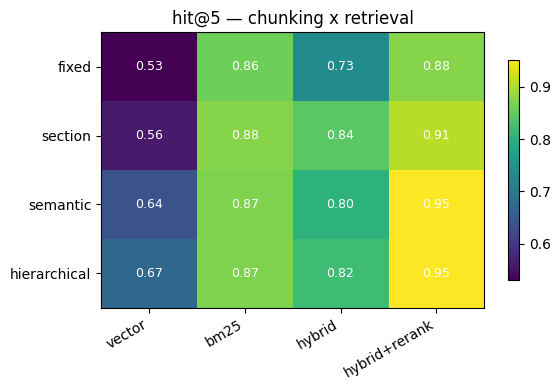

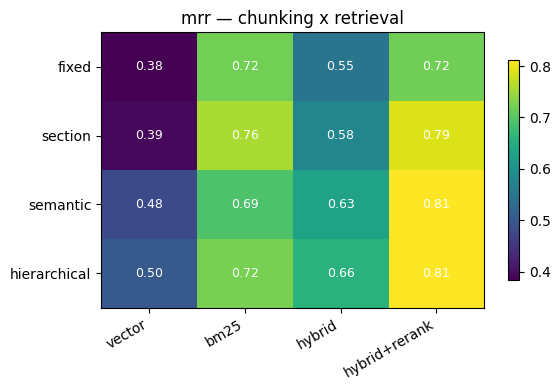

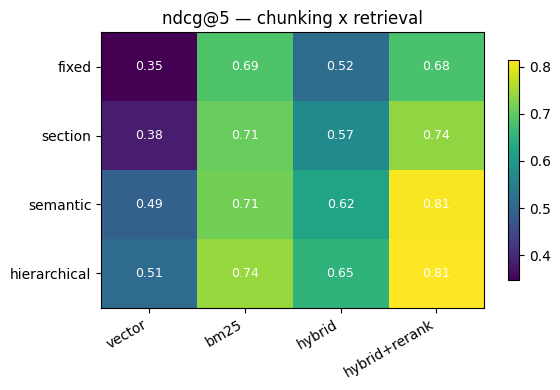

In [11]:
def plot_heatmap(matrix: pd.DataFrame, metric: str, out_path: Path) -> None:
    pivot = matrix.pivot(index='strategy', columns='mode', values=metric).reindex(index=STRATEGIES, columns=RETRIEVAL_MODES)
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_title(f'{metric} — chunking x retrieval')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.2f}' if pd.notna(val) else '-', ha='center', va='center', color='white', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout(); fig.savefig(out_path, dpi=150); plt.show()

plot_heatmap(matrix, 'hit@5', REPORTS / 'heatmap_hit_at_5.png')
plot_heatmap(matrix, 'mrr', REPORTS / 'heatmap_mrr.png')
plot_heatmap(matrix, 'ndcg@5', REPORTS / 'heatmap_ndcg_at_5.png')

## 6. Context quality — the bridge to generation

Even when retrieval is right on average, the *composition* of the top-k matters for generation: how much of the context is on-topic (context precision), how much of the on-topic context was included (context recall), and how duplicative the retrieved passages are (a high-overlap top-k wastes context budget). These are the metrics that most directly predict whether the generator will ground well.

In [13]:
def jaccard(a: str, b: str) -> float:
    ta, tb = set(a.lower().split()), set(b.lower().split())
    if not ta or not tb: return 0.0
    return len(ta & tb) / len(ta | tb)


def mean_pairwise_jaccard(texts: list[str]) -> float:
    if len(texts) < 2: return 0.0
    scores = [jaccard(texts[i], texts[j]) for i in range(len(texts)) for j in range(i + 1, len(texts))]
    return float(np.mean(scores)) if scores else 0.0


context_rows = []
for q in eval_queries:
    for strategy in STRATEGIES:
        relevant = relevance[(q['query_id'], strategy)]
        for mode in RETRIEVAL_MODES:
            hits = retriever.retrieve(q['query'], strategy=strategy, mode=mode, k=5)
            if 'text' not in hits.columns:
                hits = retriever._attach_text(hits, strategy=strategy)
            top_ids = hits['chunk_id'].tolist()
            ctx_prec = sum(1 for c in top_ids if c in relevant) / max(len(top_ids), 1) if relevant else float('nan')
            ctx_rec = (sum(1 for c in relevant if c in set(top_ids)) / len(relevant)) if relevant else float('nan')
            dup = mean_pairwise_jaccard(hits['text'].tolist())
            context_rows.append({
                'query_id': q['query_id'], 'question_type': q['question_type'], 'strategy': strategy, 'mode': mode,
                'context_precision@5': ctx_prec, 'context_recall@5': ctx_rec, 'top5_jaccard_overlap': round(dup, 3),
            })

context_df = pd.DataFrame(context_rows)
context_agg = context_df.groupby(['strategy', 'mode'])[['context_precision@5', 'context_recall@5', 'top5_jaccard_overlap']].mean().round(3).reset_index()
context_df.to_csv(DATA_PROCESSED / 'context_quality.csv', index=False)
context_agg.to_csv(DATA_PROCESSED / 'context_quality_agg.csv', index=False)
context_agg

,strategy,mode,context_precision@5,context_recall@5,top5_jaccard_overlap
0,fixed,bm25,0.268,0.708,0.281
1,fixed,hybrid,0.250,0.631,0.274
2,fixed,hybrid+rerank,0.291,0.722,0.306
3,fixed,vector,0.174,0.390,0.267
4,hierarchical,bm25,0.215,0.774,0.374
5,hierarchical,hybrid,0.215,0.717,0.358
6,hierarchical,hybrid+rerank,0.252,0.837,0.388
7,hierarchical,vector,0.185,0.597,0.399
8,section,bm25,0.259,0.706,0.279
9,section,hybrid,0.238,0.671,0.258


## 7. Optional — generation-side quality

If you supply an `llm_generate(prompt: str) -> str` function, the cell below computes:

- **Answer relevance** — cosine similarity between the answer embedding and the question embedding.
- **Answer faithfulness (proxy)** — cosine similarity between answer embedding and the concatenated retrieved context. Low values indicate the answer was ungrounded.

These are cheap, reference-free, and good enough to diff the two pipelines.

In [16]:
def build_context(chunks: pd.DataFrame, max_chars: int = 6000) -> str:
    snippets, total = [], 0
    for row in chunks.itertuples(index=False):
        snippet = f'[{row.company} | {row.form} | {row.filing_date}] {row.text}'
        if total + len(snippet) > max_chars: break
        snippets.append(snippet); total += len(snippet)
    return '\n\n'.join(snippets)


def answer_quality(query: str, answer: str, context: str, embed) -> dict:
    q_vec = embed([query])[0]; a_vec = embed([answer])[0]; c_vec = embed([context])[0]
    return {
        'answer_relevance': float(np.dot(q_vec, a_vec)),
        'answer_faithfulness': float(np.dot(a_vec, c_vec)),
    }


def run_generation_eval(queries: list[dict], llm_generate, configs: list[tuple[str, str]] = [('fixed', 'vector'), ('hierarchical', 'hybrid+rerank')]) -> pd.DataFrame:
    embed = lambda texts: np.asarray(retriever.embedding_model.encode(texts, normalize_embeddings=True), dtype='float32')
    rows = []
    for q in queries:
        for strategy, mode in configs:
            hits = retriever.retrieve(q['query'], strategy=strategy, mode=mode, k=5)
            hits = retriever._attach_text(hits, strategy=strategy)
            context = build_context(hits)
            prompt = (
                'Answer the question using only the provided SEC filing context. '
                'If the answer is not in the context, say you do not know.\n\n'
                f"Question: {q['query']}\n\nContext:\n{context}\n\nAnswer:"
            )
            answer = llm_generate(prompt)
            metrics = answer_quality(q['query'], answer, context, embed)
            rows.append({
                'query_id': q['query_id'], 'question_type': q['question_type'],
                'strategy': strategy, 'mode': mode, 'answer': answer, **metrics,
            })
    return pd.DataFrame(rows)

llm_generate = make_openai_llm(model='gpt-4o-mini')
gen_df = run_generation_eval(eval_queries, llm_generate)
gen_df.to_csv(DATA_PROCESSED / 'generation_eval.csv', index=False)
gen_df.groupby(['strategy', 'mode'])[['answer_relevance', 'answer_faithfulness']].mean().round(3)

,,answer_relevance,answer_faithfulness
strategy,mode,,
fixed,vector,0.589,0.474
hierarchical,hybrid+rerank,0.757,0.637


The final deliverable is `reports/summary.md` and `README.md` plus the CSVs under `data/processed/` (`retrieval_matrix.csv`, `retrieval_latency.csv`, `context_quality.csv`, `retrieval_per_question_type.csv`, `raw_retrieval_results.csv`). Together they support the same headline conclusion from five different angles, which is what makes the chunking and retrieval comparison defensible.